# Import Depedencies

In [ ]:
import os, warnings, string
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9
})

print('Setup Selesai')

Setup Selesai


# Load Data

In [2]:
def check_data(route):
    for dirpath, _, filenames in os.walk('../../00-datasets/'):
        if route in filenames:
            return os.path.join(dirpath, route)

df = pd.read_csv(check_data('SMSSpamCollection'), sep='\t', header=None, names=['label', 'message'])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Data Preprocessing

In [3]:
# Check Missing Value
df.isnull().sum()

label      0
message    0
dtype: int64

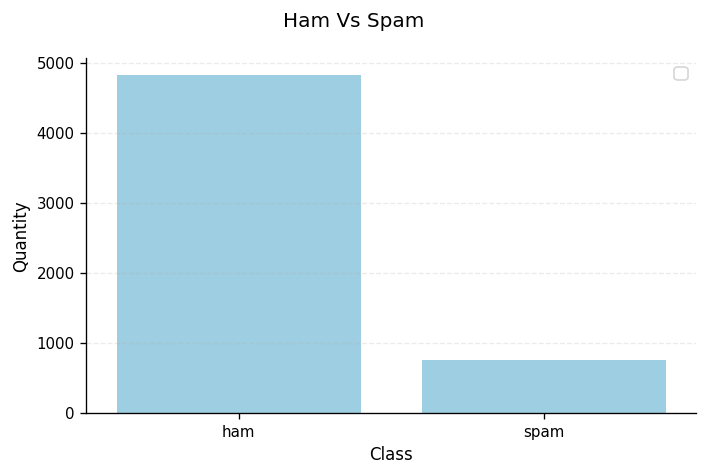

In [4]:
# Check Distribution with Plot
_, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='label', ax=ax, color='skyblue', alpha=0.9)
plt.suptitle('Ham Vs Spam')
ax.legend()
ax.set_xlabel('Class')
ax.set_ylabel('Quantity')

plt.tight_layout()
plt.show()

In [5]:
# Encoding
df['label_enc'] = df['label'].map({'ham': 0, 'spam':1})

# Cleaning
def process_text(text):  # Remove Punctuation
    text = text.lower()
    return ''.join([char for char in text if char not in string.punctuation])

df['vec_message'] = df['message'].apply(process_text)

# Vectorization
vector = CountVectorizer()
X = vector.fit_transform(df['vec_message'])  # Feature Selection
y = df['label_enc']

# Model Training

In [6]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [7]:
# Logistic Regression
model1 = LogisticRegression()
model1.fit(X_train, y_train)

# Decision Tree
model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)

# Random Forest
model3 = RandomForestClassifier()
model3.fit(X_train, y_train)

# Multinomial Naive Bayes
model4 = MultinomialNB()
model4.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [8]:
# Prediction
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)
pred4 = model4.predict(X_test)

# Model Evaluation

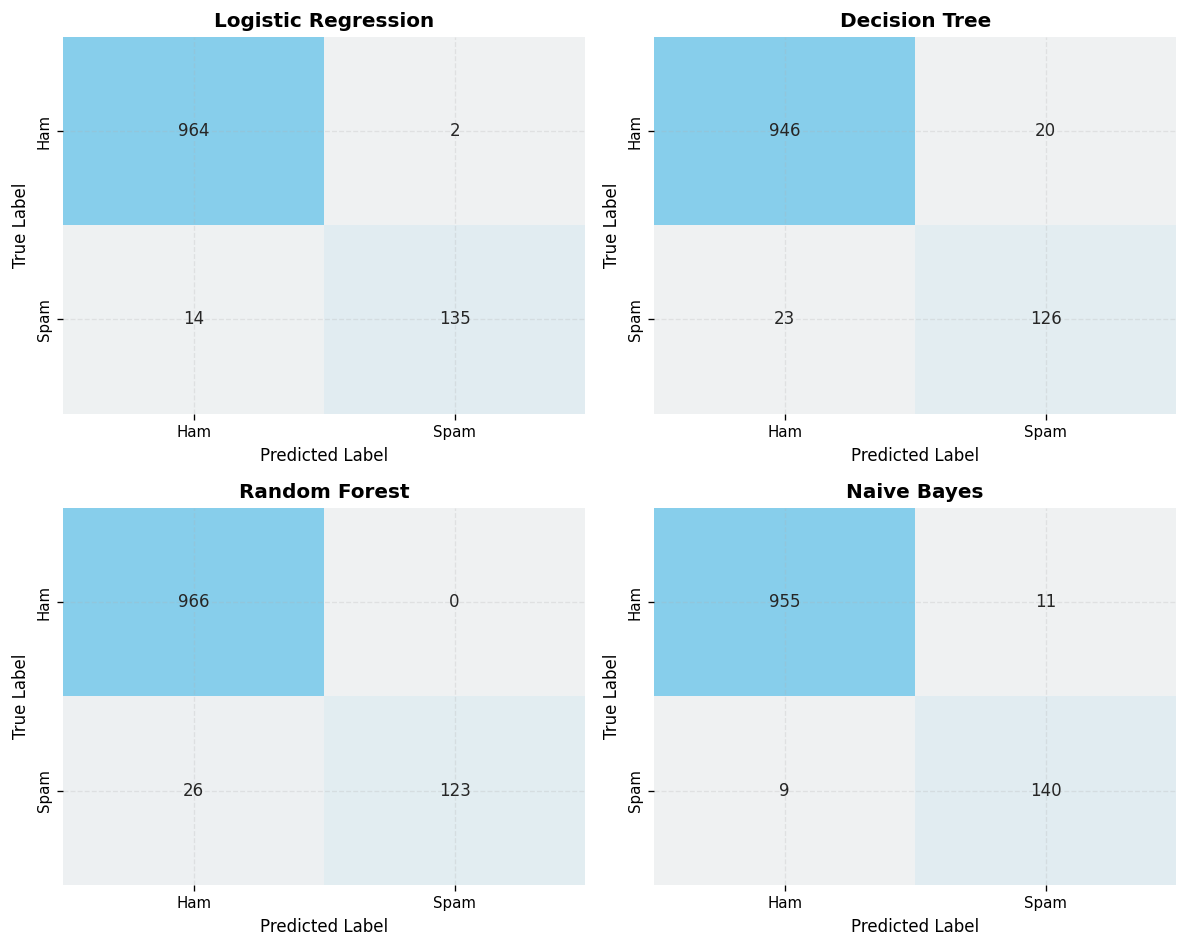

In [9]:
# Confusion Matrix
models = {
    "Logistic Regression": model1,
    "Decision Tree": model2,
    "Random Forest": model3,
    "Naive Bayes": model4
}

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

axes = ax.ravel()

for i, (name, model) in enumerate(models.items()):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=sns.light_palette('skyblue', as_cmap=True),
        cbar=False,
        xticklabels=["Ham", "Spam"],
        yticklabels=["Ham", "Spam"],
        ax=axes[i]
    )

    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [10]:
# Classification Report
pred = {
    "Logistic Regression": pred1,
    "Decision Tree": pred2,
    "Random Forest": pred3,
    "Naive Bayes": pred4
}

for name, predict in pred.items():
    report = classification_report(y_test, predict)
    print(f'Classification Report for {name}\n', report)

Classification Report for Logistic Regression
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.91      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115

Classification Report for Decision Tree
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       966
           1       0.86      0.85      0.85       149

    accuracy                           0.96      1115
   macro avg       0.92      0.91      0.92      1115
weighted avg       0.96      0.96      0.96      1115

Classification Report for Random Forest
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       966
           1       1.00      0.83      0.90       149

    accuracy                           0.98      1115